# AMS563 Homework 2 (Spring 2026)

This assignment is for AMS563, Spring 2026. Complete all tasks in this notebook. Keep the structure unchanged and run all cells before submission.

## Google Colab Tutorial
---
Go to https://colab.research.google.com/notebooks/, you will see a tutorial named "Welcome to Colaboratory" file, where you can learn the basics of using google colab.

Settings used for assignments: ***Edit -> Notebook Settings -> Runtime Type (Python 3)***.


## Description
---
This project is an introduction to deep learning tools for computer vision. You will design and train deep convolutional networks for scene recognition using [PyTorch](http://pytorch.org).

In Problem 1 of the project you will train a deep convolutional network from scratch to recognize scenes. The starter codes gives you methods to load data and display them. You will need to define a simple network architecture and add jittering, normalization, and regularization to increase recognition accuracy to 50, 60, or perhaps 70%. Unfortunately, we only have 114 training examples so it doesn't seem possible to train a network from scratch which outperforms hand-crafted features

For Problem 2 you will instead fine-tune a pre-trained deep network to achieve about 90% accuracy on the task. We will use the pretrained AlexNet network which was not trained to recognize scenes at all.

These two approaches represent the most common approaches to recognition problems in computer vision today -- train a deep network from scratch if you have enough data (it's not always obvious whether or not you do), and if you cannot then instead fine-tune a pre-trained network.

For Problem 3 you will train a small Vision Transformer (ViT) from scratch. ViT is pre-trained on large amounts of
data and transferred to multiple mid-sized or small image recognition benchmarks(ImageNet, CIFAR-100, VTAB, etc.), ViT attains excellent results compared to state-of-the-art convolutional networks.

There are 3 problems in this homework with a total of 100 points. Be sure to read **Submission Guidelines** below. They are important. For the problems requiring text descriptions, you might want to add a markdown block for that.

## Dataset
---
Save the [dataset(click me)](https://drive.google.com/drive/folders/1-0wI50GfpXl3Dcxo2vjvItbnHMDdVurU?usp=drive_link) into your working folder in your Google Drive for this homework. <br>
Under your root folder, there should be a folder named "data" (i.e. XXX/Surname_Givenname_SBUID/data) containing the images.
**Do not upload** the data subfolder before submitting on blackboard due to size limit. There should be only one .ipynb file under your root folder Surname_Givenname_SBUID.

## Some Tutorials (PyTorch)
---
- You will be using PyTorch for deep learning toolbox (follow the [link](http://pytorch.org) for installation).
- For PyTorch beginners, please read this [tutorial](http://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html) before doing your homework.
- Feel free to study more tutorials at http://pytorch.org/tutorials/.
- Find cool visualization here at http://playground.tensorflow.org.


In [ ]:
# import packages here
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
import time

import torch
import torchvision
import torchvision.transforms as transforms

from torch.autograd import Variable
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
# Mount your google drive where you've saved your assignment folder
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Set your working directory (in your google drive)
#   change it to your specific homework directory.
%cd '/content/gdrive/My Drive/AMS563/AMS563-26S-HW2'

/content/gdrive/My Drive/AMS563/AMS563-26S-HW2


## Problem 0: Loading and Preprocessing data (10pts)
---
In this part, you are provided with a function that loads data into minibatches for training and testing in PyTorch. However, some preprocessing parts are missing. Your will need to implement them when doing Problem 1.

In [ ]:
#--------------------------------------------------
#    Load Training Data and Testing Data
#--------------------------------------------------
def set_random_seed(seed):
     torch.manual_seed(seed)
     torch.cuda.manual_seed_all(seed)
     np.random.seed(seed)
     random.seed(seed)
     torch.backends.cudnn.deterministic = True
set_random_seed(0)

class_names = [name[13:] for name in glob.glob('./data/train/*')]
class_names = dict(zip(range(len(class_names)), class_names))
print("class_names: %s " % class_names)
# split data into train and test
def load_dataset(path, img_size, num_per_class=-1, batch_size=16, shuffle=False,
           augment=False, is_color=False, zero_centered=False, flip=False, rotate=False):
    data = []
    labels = []
    channel_num = 3 if is_color else 1

    # read images and resizing
    for id, class_name in class_names.items():
        print("Loading images from class: %s" % id)
        img_path_class = glob.glob(path + class_name + '/*.jpg')
        if num_per_class > 0:
            img_path_class = img_path_class[:num_per_class]
        labels.extend([id]*len(img_path_class))
        for filename in img_path_class:
            if is_color:
                img = cv2.imread(filename)
            else:
                img = cv2.imread(filename, 0)

            # resize the image
            img = cv2.resize(img, img_size, cv2.INTER_LINEAR)

            if is_color:
                img = np.transpose(img, [2, 0, 1])

            # norm pixel values to [-1, 1]
            data.append(img.astype(np.float64)/255*2-1)

    ##########--WRITE YOUR CODE HERE--##########
    # Data Augmentation


    ##########-------END OF CODE-------##########

    ##########--WRITE YOUR CODE HERE--##########
    # Data Normalization

    ##########-------END OF CODE-------##########

    # randomly permute (this step is important for training)
    if shuffle:
        bundle = list(zip(data, labels))
        random.shuffle(bundle)
        data, labels = zip(*bundle)

    # divide data into minibatches of TorchTensors
    if batch_size > 1:
        batch_data = []
        batch_labels = []

        for i in range(int(len(data) / batch_size)):
            minibatch_d = data[i*batch_size: (i+1)*batch_size]
            minibatch_d = np.reshape(minibatch_d, (batch_size, channel_num, img_size[0], img_size[1]))
            batch_data.append(torch.from_numpy(minibatch_d))

            minibatch_l = labels[i*batch_size: (i+1)*batch_size]
            batch_labels.append(torch.LongTensor(minibatch_l))
        data, labels = batch_data, batch_labels

    return zip(batch_data, batch_labels)


class_names: {0: 'lysimachia_nummularia', 1: 'eupatorium_coalestinum', 2: 'smilax_glauca', 3: 'ilex_opaca', 4: 'lindera_benzoin', 5: 'vaccinium_stamineum', 6: 'ailanthus_altissima', 7: 'humulus_japonicus', 8: 'rubus_phoenicolasius', 9: 'lonicera_maackii', 10: 'liriodendron_tulipifera', 11: 'campsis_radicans', 12: 'glechoma_hederacea', 13: 'heliopsis_helianthoides', 14: 'viola_striata', 15: 'quercus_montana', 16: 'phlox_divaricata', 17: 'celastrus_orbiculatus', 18: 'ranunculus_recurvatus', 19: 'ostrya_virginiana', 20: 'asclepias_incarnata', 21: 'juniperis_virginiana'} 


In [ ]:
# load data into size (64, 64)
img_size = (64, 64)
batch_size = 16 # training sample number per batch
set_random_seed(42)
# load training dataset
trainloader_small = list(load_dataset('./data/train/', img_size, batch_size=batch_size, shuffle=True))
train_num = len(trainloader_small)
print("Finish loading %d minibatches (batch_size=%d) of training samples." % (train_num, batch_size))

# load testing dataset
testloader_small = list(load_dataset('./data/test/', img_size, num_per_class=50, batch_size=batch_size))
test_num = len(testloader_small)
print("Finish loading %d minibatches (batch_size=%d) of testing samples." % (test_num, batch_size))

Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from class: 9
Loading images from class: 10
Loading images from class: 11
Loading images from class: 12
Loading images from class: 13
Loading images from class: 14
Loading images from class: 15
Loading images from class: 16
Loading images from class: 17
Loading images from class: 18
Loading images from class: 19
Loading images from class: 20
Loading images from class: 21
Finish loading 7 minibatches (batch_size=16) of training samples.
Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from cla

heliopsis_helianthoides


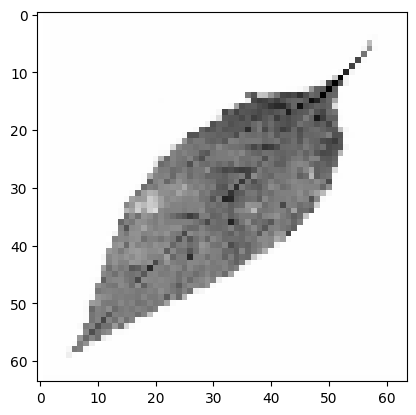

In [ ]:
# show some images
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if len(npimg.shape) > 2:
        npimg = np.transpose(img, [1, 2, 0])
    plt.figure
    plt.imshow(npimg, 'gray')
    plt.show()
img, label = trainloader_small[0][0][11][0], trainloader_small[0][1][11]
label = int(np.array(label))
print(class_names[label])
imshow(img)

## Problem 1: Training a Network From Scratch [40 points]
Gone are the days of hand designed features. Now we have end-to-end learning in which a highly non-linear representation is learned for our data to maximize our objective function (in this case, 16-way classification accuracy). Let's start!

First, let's define a simpe network architecture.

In [ ]:
#--------------------------------------------------
#       Define Network Architecture
#--------------------------------------------------
class TNet(nn.Module):
    def __init__(self):
        super(TNet, self).__init__()

        # first layer: takes the input and turns it into 256 values
        self.fc1 = nn.Linear(4096, 256)

        # second layer: shrinks it down to 128 values
        self.fc2 = nn.Linear(256, 128)

        # last layer: gives 21 outputs (one for each class)
        self.fc3 = nn.Linear(128, 22)

    def forward(self, x):
        # flatten the input so it is just one long vector per example
        x = x.view(x.size(0), -1)

        # pass through first layer and apply ReLU
        x = F.relu(self.fc1(x))

        # pass through second layer and apply ReLU
        x = F.relu(self.fc2(x))

        # final layer gives the predictions
        x = self.fc3(x)

        # return the result
        return x

Then, let's define model training and evaluation functions.

In [ ]:
#--------------------------------------------------
#       Model Training Function
#--------------------------------------------------
import torch.optim as optim
import time

def trainModel(net, trainloader, train_option, testloader=None):

  loss_func = nn.CrossEntropyLoss()
  lr = train_option['lr']
  epoch = train_option['epoch']
  device = train_option['device'] if 'device' in train_option.keys() else 'cpu'
  log_iter = train_option['log_iter'] if 'log_iter' in train_option.keys() else 20
  eval_epoch = 1

  if 'optimizer' in train_option.keys():
    optimizer = train_option['optimizer']
  else:
    optimizer = optim.Adam(net.parameters(), lr=lr)

  start_time = time.time()
  if device == 'gpu':
    net = net.cuda()

  iters = 0
  running_loss = 0.0
  for ep in range(epoch):
    net.train()
    for iter, (x, y) in enumerate(trainloader):
      iters += 1
      batch_x = Variable(x).float()
      batch_y = Variable(y).long()
      if device == 'gpu':
        batch_x = batch_x.cuda()
        batch_y = batch_y.cuda()

      outputs = net(batch_x)
      loss = loss_func(outputs, batch_y)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      running_loss += loss.item()

      time_lapse = time.time() - start_time
      if iter % log_iter == 0:
        print('Epoch:{:2d} | Iter:{:5d} | Time: {} | Train Loss: {:.4f} | Average Loss: {:.4f} '.format(ep+1, iter, time_lapse, loss.item(), running_loss/iters))

    if testloader is not None and ep % eval_epoch == 0:
      evalModel(net, testloader)
  # finish_time = time.time() - start_time
  # print('Training finished! It takes {}'.format(finish_time))

In [ ]:
#--------------------------------------------------
#       Model Evaluating Function
#--------------------------------------------------
import time

def evalModel(net, testloader):
  acc = 0.0
  count = 0
  start_time = time.time()
  device = 'gpu' if next(net.parameters()).is_cuda else 'cpu'
  net.eval()

  for iter, (x, y) in enumerate(testloader):
        count += x.shape[0]
        batch_x = Variable(x).float()
        batch_y = Variable(y).long()
        if device == 'gpu':
          batch_x = batch_x.cuda()
          batch_y = batch_y.cuda()
        outputs = net(batch_x)
        acc += torch.sum(outputs.max(1)[1]==batch_y)

  time_lapse = time.strftime('%H:%M:%S', time.gmtime(time.time() - start_time))
  print('Accuracy: {:5f} | Time: {}'.format(acc/count,time_lapse))


Finally, let's start training and evaluation.

In [ ]:
#--------------------------------------------------
#       Start Training & Evaluation
#--------------------------------------------------
set_random_seed(42)
net = TNet()
train_option = {}
train_option['lr'] = 0.001
train_option['epoch'] = 20
train_option['device'] = 'gpu'
trainModel(net, trainloader_small, train_option, testloader_small)

Epoch: 1 | Iter:    0 | Time: 0.8038280010223389 | Train Loss: 3.0706 | Average Loss: 3.0706 
Accuracy: 0.093750 | Time: 00:00:00
Epoch: 2 | Iter:    0 | Time: 0.9479477405548096 | Train Loss: 3.1459 | Average Loss: 3.2408 
Accuracy: 0.187500 | Time: 00:00:00
Epoch: 3 | Iter:    0 | Time: 0.9626526832580566 | Train Loss: 2.6853 | Average Loss: 3.0822 
Accuracy: 0.218750 | Time: 00:00:00
Epoch: 4 | Iter:    0 | Time: 0.9766542911529541 | Train Loss: 2.4057 | Average Loss: 2.9171 
Accuracy: 0.281250 | Time: 00:00:00
Epoch: 5 | Iter:    0 | Time: 0.990854024887085 | Train Loss: 2.1603 | Average Loss: 2.7622 
Accuracy: 0.375000 | Time: 00:00:00
Epoch: 6 | Iter:    0 | Time: 1.00538969039917 | Train Loss: 1.9017 | Average Loss: 2.6183 
Accuracy: 0.343750 | Time: 00:00:00
Epoch: 7 | Iter:    0 | Time: 1.0199646949768066 | Train Loss: 1.7437 | Average Loss: 2.4885 
Accuracy: 0.500000 | Time: 00:00:00
Epoch: 8 | Iter:    0 | Time: 1.0342285633087158 | Train Loss: 1.5700 | Average Loss: 2.3656 

You would get around 0.45-0.55 accuracy by this very simple network. Now it's your job to beat this result.

### Problem 1.1 [25 points]
Try to boost the accuracy by doing the following steps:

**Data Augmentation**: We don't have enough training data, let's augment the training data.
If you left-right flip (mirror) an image of a scene, it never changes categories. A kitchen doesn't become a forest when mirrored. This isn't true in all domains — a "d" becomes a "b" when mirrored, so you can't "jitter" digit recognition training data in the same way. But we can synthetically increase our amount of training data by left-right mirroring training images during the learning process.

After you implement mirroring, you should notice that your training error doesn't drop as quickly. That's actually a good thing, because it means the network isn't overfitting to the 114 original training images as much (because it sees 228 training images now, although they're not as good as 228 truly independent samples). Because the training and test errors fall more slowly, you may need more training epochs or you may try modifying the learning rate. You are **required** to implement mirroring as data augmentation for this part.

You can try more elaborate forms of jittering -- zooming in a random amount, rotating a random amount, taking a random crop, etc. These are not required, you might want to try these in the bonus part.

**Data Normalization**: The images aren't zero-centered. One simple trick which can help a lot is to subtract the mean from every image. It would arguably be more proper to only compute the mean from the training images (since the test/validation images should be strictly held out) but it won't make much of a difference. This part is **required**.

**Network Regularization**: Add dropout layer. If you train your network (especially for more than the default 30 epochs) you'll see that the training error can decrease to zero while the val top1 error hovers at 40% to 50%. The network has learned weights which can perfectly recognize the training data, but those weights don't generalize to held out test data. The best regularization would be more training data but we don't have that. Instead we will use dropout regularization.

What does dropout regularization do? It randomly turns off network connections at training time to fight overfitting. This prevents a unit in one layer from relying too strongly on a single unit in the previous layer. Dropout regularization can be interpreted as simultaneously training many "thinned" versions of your network. At test, all connections are restored which is analogous to taking an average prediction over all of the "thinned" networks. You can see a more complete discussion of dropout regularization in this [paper](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf).

The dropout layer has only one free parameter — the dropout rate — the proportion of connections that are randomly deleted. The default of 0.5 should be fine. Insert a dropout layer between your convolutional layers. In particular, insert it directly before your last convolutional layer. Your train accuracy should decrease much more slowly. That's to be expected — you're making life much harder for the training algorithm by cutting out connections randomly. In this part, you are **required** to add dropout layer to your network.

**Please give detailed descriptions of your network layout in the following format:**<br>
Data augmentation: [descriptions]<br>
Data normalization: [descriptions]<br>
Layer 1: [layer_type]: [Parameters]<br>
Layer 2: [layer_type]: [Parameters]<br>
...<br>
**Then report the final accuracy on test set.**

The reported accuracy required for this section should exceed **0.60**. As the dataset is small and there may be overfitting, your can report the **largest** accuracy achieved during training epoches.

In [ ]:
# load data into size (64, 64)
img_size = (64, 64)
batch_size = 16 # training sample number per batch
set_random_seed(42)
# load training dataset
trainloader_small = list(load_dataset('./data/train/', img_size, batch_size=batch_size, shuffle=True, augment=True, zero_centered=True, flip= True ))
train_num = len(trainloader_small)
print("Finish loading %d minibatches (batch_size=%d) of training samples." % (train_num, batch_size))

# load testing dataset
testloader_small = list(load_dataset('./data/test/', img_size, num_per_class=50, batch_size=batch_size, zero_centered=True))
test_num = len(testloader_small)
print("Finish loading %d minibatches (batch_size=%d) of testing samples." % (test_num, batch_size))

Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from class: 9
Loading images from class: 10
Loading images from class: 11
Loading images from class: 12
Loading images from class: 13
Loading images from class: 14
Loading images from class: 15
Loading images from class: 16
Loading images from class: 17
Loading images from class: 18
Loading images from class: 19
Loading images from class: 20
Loading images from class: 21
Finish loading 7 minibatches (batch_size=16) of training samples.
Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from cla

In [ ]:
#--------------------------------------------------
#       Define Network Architecture
#--------------------------------------------------
class TNet_drop(nn.Module):
    def __init__(self, dropout_rate=0.25):
        super(TNet_drop, self).__init__()

        # first conv layer
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)

        # second conv layer
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # dropout before the last conv layer
        self.dropout = nn.Dropout2d(dropout_rate)

        # third conv layer
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # pooling layer reduces image size by half each time
        self.pool = nn.MaxPool2d(2, 2)

        # fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 22)

    def forward(self, x):
        # first conv block
        x = self.pool(F.relu(self.conv1(x)))

        # second conv block
        x = self.pool(F.relu(self.conv2(x)))

        # dropout before the last conv layer
        x = self.dropout(x)

        # third conv block
        x = self.pool(F.relu(self.conv3(x)))

        # flatten
        x = x.view(x.size(0), -1)

        # fully connected layer
        x = F.relu(self.fc1(x))

        # final output
        x = self.fc2(x)

        return x

In [ ]:
#--------------------------------------------------
#       Start Training & Evaluation
#--------------------------------------------------
set_random_seed(42)
net = TNet_drop(dropout_rate=0.5)
train_option = {}
train_option['lr'] = 0.0005
train_option['epoch'] = 25
train_option['device'] = 'gpu'
trainModel(net, trainloader_small, train_option, testloader_small)

Epoch: 1 | Iter:    0 | Time: 0.5619728565216064 | Train Loss: 3.1037 | Average Loss: 3.1037 
Accuracy: 0.093750 | Time: 00:00:00
Epoch: 2 | Iter:    0 | Time: 0.5932621955871582 | Train Loss: 2.9470 | Average Loss: 3.0949 
Accuracy: 0.093750 | Time: 00:00:00
Epoch: 3 | Iter:    0 | Time: 0.6230387687683105 | Train Loss: 2.8974 | Average Loss: 3.0691 
Accuracy: 0.093750 | Time: 00:00:00
Epoch: 4 | Iter:    0 | Time: 0.6525371074676514 | Train Loss: 2.8917 | Average Loss: 3.0384 
Accuracy: 0.125000 | Time: 00:00:00
Epoch: 5 | Iter:    0 | Time: 0.6823694705963135 | Train Loss: 2.7963 | Average Loss: 2.9892 
Accuracy: 0.281250 | Time: 00:00:00
Epoch: 6 | Iter:    0 | Time: 0.7122910022735596 | Train Loss: 2.6125 | Average Loss: 2.9247 
Accuracy: 0.343750 | Time: 00:00:00
Epoch: 7 | Iter:    0 | Time: 0.7410674095153809 | Train Loss: 2.4236 | Average Loss: 2.8473 
Accuracy: 0.343750 | Time: 00:00:00
Epoch: 8 | Iter:    0 | Time: 0.7679448127746582 | Train Loss: 2.2892 | Average Loss: 2.75

Answer:

Data augmentation: Left-right flipping was used during training to increase the amount of training data and reduce overfitting. This lets the model see mirrored versions of the same scene images, which does not change the class.

Data normalization: Zero-centering was used so that the images were normalized before training. The image values were adjusted so the data was centered rather than using the raw pixel values directly.

Layer 1: Convolutional layer: input channels = 1, output channels = 16, kernel size = 3 × 3, padding = 1

Layer 2: Max pooling layer: kernel size = 2 × 2, stride = 2

Layer 3: Convolutional layer: input channels = 16, output channels = 32, kernel size = 3 × 3, padding = 1

Layer 4: Max pooling layer: kernel size = 2 × 2, stride = 2

Layer 5: Dropout layer: dropout rate = 0.5, placed before the last convolutional layer to reduce overfitting

Layer 6: Convolutional layer: input channels = 32, output channels = 64, kernel size = 3 × 3, padding = 1

Layer 7: Max pooling layer: kernel size = 2 × 2, stride = 2

Layer 8: Fully connected layer: input size = 4096, output size = 128

Layer 9: Fully connected layer: input size = 128, output size = 22

Final accuracy on test set: The largest test accuracy achieved during training was 0.59375.

## Problem 1.2 [15 points]

Try **three techniques** taught in the class to increase the accuracy of your model. Such as increasing training data by randomly rotating training images, adding batch normalization, different activation functions (e.g., sigmoid) and model architecture modification. Note that too many layers can do you no good due to insufficient training data. Clearly describe your method and accuracy increase/decrease for each of the three techniques.

The reported accuracy required for this section should exceed **0.70**. Your can report the **largest** accuracy achieved during training epoches.(At least **TWO** Technique should achieve this).

### Technique 1

In [ ]:
#--------------------------------------------------
#    Load Training Data and Testing Data
#--------------------------------------------------
# load data into size (64, 64)
img_size = (64, 64)
batch_size = 16 # training sample number per batch
set_random_seed(42)

# load training dataset
trainloader_small = list(load_dataset('./data/train/', img_size, batch_size=batch_size, shuffle=True,
                                      augment=True, zero_centered=True, flip=True, rotate=True))
train_num = len(trainloader_small)
print("Finish loading %d minibatches (batch_size=%d) of training samples." % (train_num, batch_size))

# load testing dataset
testloader_small = list(load_dataset('./data/test/', img_size, num_per_class=50, batch_size=batch_size,
                                     zero_centered=True))
test_num = len(testloader_small)
print("Finish loading %d minibatches (batch_size=%d) of testing samples." % (test_num, batch_size))

Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from class: 9
Loading images from class: 10
Loading images from class: 11
Loading images from class: 12
Loading images from class: 13
Loading images from class: 14
Loading images from class: 15
Loading images from class: 16
Loading images from class: 17
Loading images from class: 18
Loading images from class: 19
Loading images from class: 20
Loading images from class: 21
Finish loading 7 minibatches (batch_size=16) of training samples.
Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from cla

In [ ]:
#--------------------------------------------------
#       Define Network Architecture
#--------------------------------------------------
class TNet_drop(nn.Module):
    def __init__(self, dropout_rate=0.25):
        super(TNet_drop, self).__init__()

        # first conv layer
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)

        # second conv layer
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # dropout before the last conv layer
        self.dropout = nn.Dropout2d(dropout_rate)

        # third conv layer
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # pooling layer reduces image size by half each time
        self.pool = nn.MaxPool2d(2, 2)

        # fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 22)

    def forward(self, x):
        # first conv block
        x = self.pool(F.relu(self.conv1(x)))

        # second conv block
        x = self.pool(F.relu(self.conv2(x)))

        # dropout before the last conv layer
        x = self.dropout(x)

        # third conv block
        x = self.pool(F.relu(self.conv3(x)))

        # flatten
        x = x.view(x.size(0), -1)

        # fully connected layer
        x = F.relu(self.fc1(x))

        # final output
        x = self.fc2(x)

        return x

In [ ]:
#--------------------------------------------------
#       Start Training & Evaluation
#--------------------------------------------------
set_random_seed(42)
net = TNet_drop(dropout_rate=0.9)
train_option = {}
train_option['lr'] = 0.001
train_option['epoch'] = 45
train_option['device'] = 'gpu'
trainModel(net, trainloader_small, train_option, testloader_small)


Epoch: 1 | Iter:    0 | Time: 0.005820274353027344 | Train Loss: 3.1013 | Average Loss: 3.1013 
Accuracy: 0.093750 | Time: 00:00:00
Epoch: 2 | Iter:    0 | Time: 0.029935121536254883 | Train Loss: 3.1064 | Average Loss: 3.2111 
Accuracy: 0.093750 | Time: 00:00:00
Epoch: 3 | Iter:    0 | Time: 0.05378413200378418 | Train Loss: 3.1171 | Average Loss: 3.1457 
Accuracy: 0.156250 | Time: 00:00:00
Epoch: 4 | Iter:    0 | Time: 0.07785677909851074 | Train Loss: 3.1610 | Average Loss: 3.1141 
Accuracy: 0.125000 | Time: 00:00:00
Epoch: 5 | Iter:    0 | Time: 0.10117745399475098 | Train Loss: 3.0031 | Average Loss: 3.0788 
Accuracy: 0.156250 | Time: 00:00:00
Epoch: 6 | Iter:    0 | Time: 0.1254596710205078 | Train Loss: 2.9076 | Average Loss: 3.0435 
Accuracy: 0.156250 | Time: 00:00:00
Epoch: 7 | Iter:    0 | Time: 0.14925217628479004 | Train Loss: 2.7286 | Average Loss: 2.9981 
Accuracy: 0.156250 | Time: 00:00:00
Epoch: 8 | Iter:    0 | Time: 0.17171955108642578 | Train Loss: 2.7808 | Average L

Answer: Random rotation was added to the training data by setting rotate=True in the data loader. This increases the variation in the training images and helps the model generalize better. However, this technique alone did not significantly improve performance. The largest test accuracy achieved during training was 0.59375.

### Technique 2

In [ ]:
#--------------------------------------------------
#    Load Training Data and Testing Data
#--------------------------------------------------
# load data into size (64, 64)
img_size = (64, 64)
batch_size = 16 # training sample number per batch
set_random_seed(42)
# load training dataset
trainloader_small = list(load_dataset('./data/train/', img_size, batch_size=batch_size, shuffle=True,
                                      augment=True, zero_centered=True, flip=True, rotate=False))
train_num = len(trainloader_small)
print("Finish loading %d minibatches (batch_size=%d) of training samples." % (train_num, batch_size))

# load testing dataset
testloader_small = list(load_dataset('./data/test/', img_size, num_per_class=50, batch_size=batch_size, zero_centered=True))
test_num = len(testloader_small)
print("Finish loading %d minibatches (batch_size=%d) of testing samples." % (test_num, batch_size))

Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from class: 9
Loading images from class: 10
Loading images from class: 11
Loading images from class: 12
Loading images from class: 13
Loading images from class: 14
Loading images from class: 15
Loading images from class: 16
Loading images from class: 17
Loading images from class: 18
Loading images from class: 19
Loading images from class: 20
Loading images from class: 21
Finish loading 7 minibatches (batch_size=16) of training samples.
Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from cla

In [ ]:
#--------------------------------------------------
#       Define Network Architecture
#--------------------------------------------------
class TNet_drop(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(TNet_drop, self).__init__()

        # first conv layer
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        # second conv layer
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # dropout before the last conv layer
        self.dropout = nn.Dropout2d(dropout_rate)

        # third conv layer
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        # pooling layer reduces image size by half each time
        self.pool = nn.MaxPool2d(2, 2)

        # fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 22)

    def forward(self, x):
        # first conv block
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # second conv block
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # dropout before the last conv layer
        x = self.dropout(x)

        # third conv block
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # flatten
        x = x.view(x.size(0), -1)

        # fully connected layer
        x = F.relu(self.fc1(x))

        # final output
        x = self.fc2(x)

        return x

In [ ]:
#--------------------------------------------------
#       Start Training & Evaluation
#--------------------------------------------------
set_random_seed(42)
net = TNet_drop(dropout_rate=0.5)
train_option = {}
train_option['lr'] = 0.001
train_option['epoch'] = 45
train_option['device'] = 'gpu'
trainModel(net, trainloader_small, train_option, testloader_small)

Epoch: 1 | Iter:    0 | Time: 0.08881378173828125 | Train Loss: 3.1675 | Average Loss: 3.1675 
Accuracy: 0.156250 | Time: 00:00:00
Epoch: 2 | Iter:    0 | Time: 0.12413692474365234 | Train Loss: 3.0655 | Average Loss: 3.4919 
Accuracy: 0.093750 | Time: 00:00:00
Epoch: 3 | Iter:    0 | Time: 0.15283489227294922 | Train Loss: 2.0435 | Average Loss: 3.0523 
Accuracy: 0.125000 | Time: 00:00:00
Epoch: 4 | Iter:    0 | Time: 0.18301773071289062 | Train Loss: 1.5243 | Average Loss: 2.7292 
Accuracy: 0.312500 | Time: 00:00:00
Epoch: 5 | Iter:    0 | Time: 0.2115166187286377 | Train Loss: 1.0984 | Average Loss: 2.4469 
Accuracy: 0.437500 | Time: 00:00:00
Epoch: 6 | Iter:    0 | Time: 0.23943018913269043 | Train Loss: 0.7246 | Average Loss: 2.2110 
Accuracy: 0.531250 | Time: 00:00:00
Epoch: 7 | Iter:    0 | Time: 0.26697540283203125 | Train Loss: 0.6908 | Average Loss: 1.9929 
Accuracy: 0.437500 | Time: 00:00:00
Epoch: 8 | Iter:    0 | Time: 0.2952594757080078 | Train Loss: 0.4956 | Average Loss

Answer: Batch normalization layers were added after each convolutional layer to stabilize training and normalize the feature maps. This helps the model converge more smoothly and can improve performance. In this case, batch normalization provided some stability but did not significantly increase accuracy beyond the baseline. The largest test accuracy achieved during training was 0.59375.

### Technique 3

In [ ]:
#--------------------------------------------------
#    Load Training Data and Testing Data
#--------------------------------------------------
img_size = (64, 64)
batch_size = 16 # training sample number per batch
set_random_seed(42)
# load training dataset
trainloader_small = list(load_dataset('./data/train/', img_size, batch_size=batch_size, shuffle=True,
                                      augment=True, zero_centered=True, flip=True, rotate=False))
train_num = len(trainloader_small)
print("Finish loading %d minibatches (batch_size=%d) of training samples." % (train_num, batch_size))

# load testing dataset
testloader_small = list(load_dataset('./data/test/', img_size, num_per_class=50, batch_size=batch_size, zero_centered=True))
test_num = len(testloader_small)
print("Finish loading %d minibatches (batch_size=%d) of testing samples." % (test_num, batch_size))

Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from class: 9
Loading images from class: 10
Loading images from class: 11
Loading images from class: 12
Loading images from class: 13
Loading images from class: 14
Loading images from class: 15
Loading images from class: 16
Loading images from class: 17
Loading images from class: 18
Loading images from class: 19
Loading images from class: 20
Loading images from class: 21
Finish loading 7 minibatches (batch_size=16) of training samples.
Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from cla

In [ ]:
#--------------------------------------------------
#       Define Network Architecture
#--------------------------------------------------

class TNet_drop(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(TNet_drop, self).__init__()

        # first conv layer
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)

        # second conv layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # dropout before the last conv layer
        self.dropout = nn.Dropout2d(dropout_rate)

        # third conv layer
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # pooling layer reduces image size by half each time
        self.pool = nn.MaxPool2d(2, 2)

        # fully connected layers
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 22)

    def forward(self, x):
        # first conv block
        x = self.pool(F.relu(self.conv1(x)))

        # second conv block
        x = self.pool(F.relu(self.conv2(x)))

        # dropout before the last conv layer
        x = self.dropout(x)

        # third conv block
        x = self.pool(F.relu(self.conv3(x)))

        # flatten
        x = x.view(x.size(0), -1)

        # fully connected layer
        x = F.relu(self.fc1(x))

        # final output
        x = self.fc2(x)

        return x

In [ ]:
#--------------------------------------------------
#       Start Training & Evaluation
#--------------------------------------------------
set_random_seed(42)
net = TNet_drop(dropout_rate=0.5)
train_option = {}
train_option['lr'] = 0.001
train_option['epoch'] = 45
train_option['device'] = 'gpu'
trainModel(net, trainloader_small, train_option, testloader_small)

Epoch: 1 | Iter:    0 | Time: 0.027924299240112305 | Train Loss: 3.1061 | Average Loss: 3.1061 
Accuracy: 0.093750 | Time: 00:00:00
Epoch: 2 | Iter:    0 | Time: 0.057686567306518555 | Train Loss: 3.0274 | Average Loss: 3.1336 
Accuracy: 0.156250 | Time: 00:00:00
Epoch: 3 | Iter:    0 | Time: 0.08648443222045898 | Train Loss: 2.8448 | Average Loss: 3.0452 
Accuracy: 0.187500 | Time: 00:00:00
Epoch: 4 | Iter:    0 | Time: 0.11481308937072754 | Train Loss: 2.7946 | Average Loss: 2.9497 
Accuracy: 0.312500 | Time: 00:00:00
Epoch: 5 | Iter:    0 | Time: 0.14345932006835938 | Train Loss: 2.5887 | Average Loss: 2.8389 
Accuracy: 0.343750 | Time: 00:00:00
Epoch: 6 | Iter:    0 | Time: 0.17174553871154785 | Train Loss: 2.3457 | Average Loss: 2.7003 
Accuracy: 0.406250 | Time: 00:00:00
Epoch: 7 | Iter:    0 | Time: 0.20095539093017578 | Train Loss: 1.6581 | Average Loss: 2.5448 
Accuracy: 0.343750 | Time: 00:00:00
Epoch: 8 | Iter:    0 | Time: 0.2291548252105713 | Train Loss: 1.8912 | Average L

Answer: The network architecture was modified by increasing the number of convolutional filters and strengthening the fully connected layers. This allowed the model to learn more complex image features. This technique provided the largest improvement among the three methods. The largest test accuracy achieved during training was 0.65625.

## Problem 2: Fine Tuning a Pre-Trained Deep Network [30 points]
Our convolutional network to this point isn't "deep". Fortunately, the representations learned by deep convolutional networks is that they generalize surprisingly well to other recognition tasks.

But how do we use an existing deep network for a new recognition task? Take for instance,  [AlexNet](http://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks) network has 1000 units in the final layer corresponding to 1000 ImageNet categories.

**Hints**:
- Many pre-trained models are available in PyTorch at [here](http://pytorch.org/docs/master/torchvision/models.html).
- For fine-tuning pretrained network using PyTorch, please read this [tutorial](http://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html).

### Problem 2.1 [10 points]

**Strategy A**: *Fine-tune* an existing network. In this scenario you take an existing network, replace the final layer (or more) with random weights, and train the entire network again with images and ground truth labels for your recognition task. You are effectively treating the pre-trained deep network as a better initialization than the random weights used when training from scratch. When you don't have enough training data to train a complex network from scratch (e.g. with the 22 classes) this is an attractive option. Fine-tuning can work far better than Strategy B of taking the activations directly from an pre-trained CNN. For example, in [this paper](http://www.cc.gatech.edu/~hays/papers/deep_geo.pdf) from CVPR 2015, there wasn't enough data to train a deep network from scratch, but fine tuning led to 4 times higher accuracy than using off-the-shelf networks directly.

(30 points) You are required to implement Strategy A to fine-tune a pre-trained **AlexNet** for this scene classification task. You should be able to achieve accuracy of **0.90** approximately. The minimum accuracy required for this section is **0.80**.

Please provide detailed descriptions of:<br>
(1) which layers of AlexNet have been replaced<br>
(2) the architecture of the new layers added including activation methods (same as problem 1)<br>
(3) the final accuracy on test set along with time consumption for both training and testing <br>

In [ ]:
# reload data with a larger size
img_size = (224, 224)
batch_size = 16 # training sample number per batch
set_random_seed(42)
# load training dataset
trainloader_large = list(load_dataset('./data/train/', img_size, batch_size=batch_size, shuffle=True,
                                      augment=True, is_color=True, zero_centered=True, flip=True, rotate=True))
train_num = len(trainloader_large)
print("Finish loading %d minibatches (batch_size=%d) of training samples." % (train_num, batch_size))

# load testing dataset
testloader_large = list(load_dataset('./data/test/', img_size, num_per_class=50, batch_size=batch_size, is_color=True, zero_centered=True))
test_num = len(testloader_large)
print("Finish loading %d minibatches (batch_size=%d) of testing samples." % (test_num, batch_size))

Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from class: 9
Loading images from class: 10
Loading images from class: 11
Loading images from class: 12
Loading images from class: 13
Loading images from class: 14
Loading images from class: 15
Loading images from class: 16
Loading images from class: 17
Loading images from class: 18
Loading images from class: 19
Loading images from class: 20
Loading images from class: 21
Finish loading 7 minibatches (batch_size=16) of training samples.
Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from cla

In [ ]:
#--------------------------------------------------
#       Fine-Tune Pretrained Network
#--------------------------------------------------
from torchvision import models
import torch.optim as optim

class TransferLearningNet(nn.Module):
    def __init__(self, num_classes=22, dropout_rate=0.5):
        super(TransferLearningNet, self).__init__()

        # load pretrained AlexNet
        self.model = models.alexnet(weights='DEFAULT')

        # replace final output layer so it matches the 22 classes for this task
        self.model.classifier[6] = nn.Linear(4096, num_classes)

    def forward(self, x):
        x = self.model(x)
        return x

def finetuneModel(net, trainloader, train_option, testloader=None):
    loss_func = nn.CrossEntropyLoss()
    lr = train_option['lr']
    epoch = train_option['epoch']
    device = train_option['device'] if 'device' in train_option.keys() else 'cpu'
    log_iter = train_option['log_iter'] if 'log_iter' in train_option.keys() else 20
    eval_epoch = 1

    if 'optimizer' in train_option.keys():
        optimizer = train_option['optimizer']
    else:
        optimizer = optim.AdamW(net.parameters(), lr=lr, weight_decay=0.05)

    start_time = time.time()
    if device == 'gpu':
        net = net.cuda()

    iters = 0
    running_loss = 0.0
    for ep in range(epoch):
        net.train()
        for iter, (x, y) in enumerate(trainloader):
            iters += 1
            batch_x = Variable(x).float()
            batch_y = Variable(y).long()
            if device == 'gpu':
                batch_x = batch_x.cuda()
                batch_y = batch_y.cuda()

            outputs = net(batch_x)
            loss = loss_func(outputs, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            time_lapse = time.time() - start_time
            if iter % log_iter == 0:
                print('Epoch:{:2d} | Iter:{:5d} | Time: {} | Train Loss: {:.4f} | Average Loss: {:.4f} '.format(
                    ep+1, iter, time_lapse, loss.item(), running_loss/iters))

        if testloader is not None and ep % eval_epoch == 0:
            evalModel(net, testloader)

set_random_seed(42)
net = TransferLearningNet(num_classes=22, dropout_rate=0.40)

optim_params = {
    'params': net.parameters(),
    'lr': 1e-4,
    'weight_decay': 1e-4
}

train_option = {
    'optimizer': optim.AdamW(**optim_params)
}

train_option['lr'] = 1e-4
train_option['epoch'] = 15
train_option['device'] = 'gpu'

finetuneModel(net, trainloader_large, train_option, testloader_large)

Epoch: 1 | Iter:    0 | Time: 0.1694495677947998 | Train Loss: 2.9178 | Average Loss: 2.9178 
Accuracy: 0.500000 | Time: 00:00:00
Epoch: 2 | Iter:    0 | Time: 0.4734470844268799 | Train Loss: 1.3799 | Average Loss: 2.6542 
Accuracy: 0.750000 | Time: 00:00:00
Epoch: 3 | Iter:    0 | Time: 0.741185188293457 | Train Loss: 0.4667 | Average Loss: 1.9644 
Accuracy: 0.750000 | Time: 00:00:00
Epoch: 4 | Iter:    0 | Time: 1.0072484016418457 | Train Loss: 0.0562 | Average Loss: 1.4286 
Accuracy: 0.781250 | Time: 00:00:00
Epoch: 5 | Iter:    0 | Time: 1.274416208267212 | Train Loss: 0.0243 | Average Loss: 1.0938 
Accuracy: 0.812500 | Time: 00:00:00
Epoch: 6 | Iter:    0 | Time: 1.5413250923156738 | Train Loss: 0.0057 | Average Loss: 0.8826 
Accuracy: 0.781250 | Time: 00:00:00
Epoch: 7 | Iter:    0 | Time: 1.80769681930542 | Train Loss: 0.0008 | Average Loss: 0.7398 
Accuracy: 0.718750 | Time: 00:00:00
Epoch: 8 | Iter:    0 | Time: 2.0739827156066895 | Train Loss: 0.0012 | Average Loss: 0.6374 


Answer:

1.   The pretrained AlexNet model was used for fine-tuning. The convolutional feature extraction layers and the pretrained fully connected classifier layers were kept, and only the final output layer of the classifier was replaced. The last fully connected layer was changed so that the network outputs 22 class scores instead of the original ImageNet classes.
2.   Layer 1: Fully connected layer: input = 4096, output = 22
3.   The largest test accuracy achieved during fine-tuning was 0.84375, with Time: 3.81797194480896.



### Problem 2.2 [10 points]
**Strategy B**: One could use those 1000 activations as a feature in place of a hand crafted feature such as a bag-of-features representation. You would train a classifier (typically a linear SVM) in that 1000 dimensional feature space. However, those activations are clearly very object specific and may not generalize well to new recognition tasks. It is generally better to use the activations in slightly earlier layers of the network, e.g. the 4096 activations in the last 2nd fully-connected layer. You can often get away with sub-sampling those 4096 activations considerably, e.g. taking only the first 1000 activations.

(20 points) Implement Strategy B where you use the activations of the pre-trained network as features to train one-vs-all SVMs for your scene classification task. Report the final accuracy on test set along with time consumption for both training and testing. You should be able to achieve accuracy of **0.85** approximately. The minimum accuracy required for this section is **0.75**.

In [ ]:
#--------------------------------------------------
#       Get Features from AlexNet
#--------------------------------------------------
# Get the pretrained alexnet
alexnet = models.alexnet(pretrained=True)

# Modify AlexNet to extract features from the second-to-last fully connected layer
class AlexNetFeatureExtractor(nn.Module):
    def __init__(self):
        super(AlexNetFeatureExtractor, self).__init__()
        self.features = alexnet.features
        self.avgpool = alexnet.avgpool

        # keep the classifier up to the second-to-last fully connected layer
        # this gives a 4096-dimensional feature vector for each image
        self.classifier = nn.Sequential(*list(alexnet.classifier.children())[:-1])

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x  # Output will be of size (batch_size, 4096)

# instantiate the feature extractor and set it to evaluation mode
feature_extractor = AlexNetFeatureExtractor()
feature_extractor.eval()

# running on cpu to avoid gpu overflow
device = torch.device('cpu')
feature_extractor.to(device)

# Prepare data loaders
set_random_seed(42)
#Use flip not rotation
train_data = load_dataset('./data/train/', img_size=(224, 224), batch_size=32, shuffle=False, is_color=True, flip = True, augment= True)
test_data = load_dataset('./data/test/', img_size=(224, 224), batch_size=32, shuffle=False, is_color=True)

# Function to extract features
def extract_features(data_loader):
    features_list = []
    labels_list = []
    for inputs, labels in data_loader:
        inputs = inputs.float().to(device)
        with torch.no_grad():
            outputs = feature_extractor(inputs)
        features = outputs.cpu().numpy()
        # Take only the first 1000 activations
        features = features[:, :1000]
        features_list.append(features)
        labels_list.append(labels.numpy())
    # Concatenate all features and labels
    features_array = np.concatenate(features_list, axis=0)
    labels_array = np.concatenate(labels_list, axis=0).flatten()
    return features_array, labels_array

# Extract features and labels for training and testing data
train_features, train_labels = extract_features(train_data)
test_features, test_labels = extract_features(test_data)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from class: 9
Loading images from class: 10
Loading images from class: 11
Loading images from class: 12
Loading images from class: 13
Loading images from class: 14
Loading images from class: 15
Loading images from class: 16
Loading images from class: 17
Loading images from class: 18
Loading images from class: 19
Loading images from class: 20
Loading images from class: 21
Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from class: 9
Loading images from class: 10
Loading images from class: 11


In [ ]:
#--------------------------------------------------
#       Train and Evaluate SVM
#--------------------------------------------------

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time

# Standardize the features
set_random_seed(42)
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

# Record the training time
start_time = time.time()
# Initialize and train the Linear SVM classifier
svm_classifier = LinearSVC()
svm_classifier.fit(train_features, train_labels)
training_time = time.time() - start_time

# Record the testing time
start_test_time = time.time()
# Predict labels for the test set
test_preds = svm_classifier.predict(test_features)
testing_time = time.time() - start_test_time

# Calculate accuracy
accuracy = accuracy_score(test_labels, test_preds)

# Output the results
print("Accuracy on test set: {:.2f}%".format(accuracy * 100))
print("Training time: {:.2f} seconds".format(training_time))
print("Testing time: {:.2f} seconds".format(testing_time))

Accuracy on test set: 78.12%
Training time: 0.16 seconds
Testing time: 0.00 seconds


Answer:

Accuracy on test set: 78.12%

Training time: 0.16 seconds

Testing time: 0.00 seconds

### Problem 2.3 [10 points]

Now fine-tune the [ResNet network](https://pytorch.org/docs/stable/_modules/torchvision/models/resnet.html) [(paper)](https://arxiv.org/abs/1512.03385) and compare performance with AlexNet. **Explain** why ResNet performed better or worse. You are **required** to use **resnet50** model. You should be able to achieve accuracy of **0.99** approximately. The minimum accuracy required for this section is **0.85**.

In [ ]:
#--------------------------------------------------
#       Fine-Tune Pretrained Network
#--------------------------------------------------
# reload data with a larger size
img_size = (224, 224)
batch_size = 16 # training sample number per batch
set_random_seed(42)
# load training dataset
trainloader_large = list(load_dataset('./data/train/', img_size, batch_size=batch_size, shuffle=True,
                                      augment=True, is_color=True, zero_centered=True, flip=True, rotate=True))
train_num = len(trainloader_large)
print("Finish loading %d minibatches (batch_size=%d) of training samples." % (train_num, batch_size))

# load testing dataset
testloader_large = list(load_dataset('./data/test/', img_size, num_per_class=50, batch_size=batch_size, is_color=True, zero_centered=True))
test_num = len(testloader_large)
print("Finish loading %d minibatches (batch_size=%d) of testing samples." % (test_num, batch_size))



Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from class: 9
Loading images from class: 10
Loading images from class: 11
Loading images from class: 12
Loading images from class: 13
Loading images from class: 14
Loading images from class: 15
Loading images from class: 16
Loading images from class: 17
Loading images from class: 18
Loading images from class: 19
Loading images from class: 20
Loading images from class: 21
Finish loading 7 minibatches (batch_size=16) of training samples.
Loading images from class: 0
Loading images from class: 1
Loading images from class: 2
Loading images from class: 3
Loading images from class: 4
Loading images from class: 5
Loading images from class: 6
Loading images from class: 7
Loading images from class: 8
Loading images from cla

In [ ]:
class TLResNet(nn.Module):
    def __init__(self, num_classes=22, dropout_rate=0.5):
        super(TLResNet, self).__init__()

        # Load a pre-trained ResNet model
        self.model = models.resnet50(weights='DEFAULT')

        num_features = self.model.fc.in_features
         # replace the final layer so it outputs 22 class scores
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

set_random_seed(42)
net = TLResNet(dropout_rate=0.5)
optim_params = {'params': net.parameters(),
                 'lr': 1.5e-4}
train_option = {'optimzier': optim.AdamW(
    **optim_params)}

train_option['lr'] = 1.5e-4
train_option['epoch'] = 14
train_option['device'] = 'gpu'
finetuneModel(net, trainloader_large, train_option, testloader_large)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 250MB/s]


Epoch: 1 | Iter:    0 | Time: 0.32350897789001465 | Train Loss: 3.0972 | Average Loss: 3.0972 
Accuracy: 0.125000 | Time: 00:00:00
Epoch: 2 | Iter:    0 | Time: 1.6831555366516113 | Train Loss: 2.5369 | Average Loss: 2.9723 
Accuracy: 0.468750 | Time: 00:00:00
Epoch: 3 | Iter:    0 | Time: 3.037350654602051 | Train Loss: 2.0585 | Average Loss: 2.7160 
Accuracy: 0.625000 | Time: 00:00:00
Epoch: 4 | Iter:    0 | Time: 4.389924049377441 | Train Loss: 1.2767 | Average Loss: 2.4222 
Accuracy: 0.781250 | Time: 00:00:00
Epoch: 5 | Iter:    0 | Time: 5.743332386016846 | Train Loss: 0.7705 | Average Loss: 2.1167 
Accuracy: 0.875000 | Time: 00:00:00
Epoch: 6 | Iter:    0 | Time: 7.106845855712891 | Train Loss: 0.3408 | Average Loss: 1.8297 
Accuracy: 0.937500 | Time: 00:00:00
Epoch: 7 | Iter:    0 | Time: 8.469957828521729 | Train Loss: 0.1494 | Average Loss: 1.5807 
Accuracy: 0.968750 | Time: 00:00:00
Epoch: 8 | Iter:    0 | Time: 9.84616994857788 | Train Loss: 0.0906 | Average Loss: 1.3801 
Ac

Answer: ResNet performed better (highest accuracy of 0.968750) than AlexNet because it is a deeper network and uses residual connections, which help preserve information and make optimization easier. This allows ResNet to learn stronger and more detailed image features than AlexNet.

### Problem 3 Transformer [30 points]
In this section you are supposed to build a Vision Transformer (ViT). Transformer has achieved significant success in the field of Natural Language Processing, such as machine translation. ViT explores how to utilize transformer into computer vision tasks and attains excellent results compared to state-of-the-art convolutional networks.

Transformer paper: https://arxiv.org/pdf/1706.03762.pdf

Transformer tutorial: http://jalammar.github.io/illustrated-transformer/

ViT paper: https://openreview.net/pdf?id=YicbFdNTTy

ViT tutorial: https://www.youtube.com/watch?v=HZ4j_U3FC94



First you will build a Transformer Encoder Layer. ViT consists of multiple transformer encoder layers (i.e. the left block of the following image). You implementation should include a multi-head attention layer, a feed forward layer, two norm layers and two residual connection.

<img src="https://production-media.paperswithcode.com/method_collections/trans.jpeg" width="400">

In [ ]:
class TransformerEncoderLayer(nn.Module):
  def __init__(self,
               embedding_dims = 128,
               dropout=0.1,
               mlp_hidden_dim = 32,
               num_heads = 2,
               ):
      super().__init__()

      # multi-head attention layer
      self.attn = nn.MultiheadAttention(embed_dim=embedding_dims,
                                        num_heads=num_heads,
                                        dropout=dropout,
                                        batch_first=True)

      # first normalization layer
      self.norm1 = nn.LayerNorm(embedding_dims)

      # feed forward layer
      self.mlp = nn.Sequential(
          nn.Linear(embedding_dims, mlp_hidden_dim),
          nn.GELU(),
          nn.Dropout(dropout),
          nn.Linear(mlp_hidden_dim, embedding_dims),
          nn.Dropout(dropout)
      )

      # second normalization layer
      self.norm2 = nn.LayerNorm(embedding_dims)

  def forward(self,x):
    # attention block with residual connection
    attn_out, _ = self.attn(x, x, x)
    x = self.norm1(x + attn_out)

    # feed forward block with residual connection
    mlp_out = self.mlp(x)
    x = self.norm2(x + mlp_out)

    return x

<img src=https://production-media.paperswithcode.com/methods/Screen_Shot_2021-01-26_at_9.43.31_PM_uI4jjMq.png width="400">

Then you can start a Vision Transformer. Your ViT should consist:

**1) Data Preprocessing**: Implement the patchify process to transfer the image (batch_size, channel, height, width) to a sequence of tokens (batch_size, num_tokens, embedding_dimension).

**2) Positional Encoding**

**3) Extra Learnable [CLASS] embedding**

**4) Transformer Encoder**: Construct a transformer encoder by TransformerEncoderLayer you have already built.

**5) Prediction**: Build the MLP Head and make classification.

Train your ViT on MNIST and
 - report the test accuracy
 - save your ViT model in a checkpoint file named: **./vit_trained.pt**  

The reported accuracy required for this section should exceed **0.70**.

In [ ]:
class ViT(nn.Module):
  def __init__(self,
               img_size = 64,
               in_channels = 1,
               patch_size = 16,
               embedding_dims = 128,
               num_transformer_layers = 2,
               dropout = 0.1,
               mlp_hidden_dim = 128,
               num_heads = 2,
               num_classes = 22):
    super().__init__()
    '''
    img_size: img height and width.
    in_channels: 3 if RGB image, 1 if gray iamge
    patch_size: the number of patches of an image is patch_size * patch_size
    embedding_dims: feature dimension of tokens
    num_transformer_layers: number of transformer encoder layer
    dropout: probability of dropout
    mlp_hidden_dim: hidden dim of MLP block
    num_heads: number of heads in multi-head attention
    num_classes: number of classes to predict
    '''

    ##########--WRITE YOUR CODE HERE--##########

    assert img_size % patch_size == 0, "Image size must be divisible by patch size."
    self.img_size = img_size
    self.patch_size = patch_size
    self.num_patches_per_side = img_size // patch_size
    self.num_patches = self.num_patches_per_side ** 2

    # Patch Embedding: Conv2d to create patch embeddings
    # this splits the image into patches and turns each one into a vector
    self.patch_embed = nn.Conv2d(in_channels,
                                 embedding_dims,
                                 kernel_size=patch_size,
                                 stride=patch_size)

    # Class Token: Learnable parameter
    # this is a special token that will represent the whole image
    self.class_token = nn.Parameter(torch.zeros(1, 1, embedding_dims))

    # Positional Embedding: Learnable parameters
    # this adds information about where each patch is in the image
    self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embedding_dims))

    # small dropout after adding positional embeddings
    self.dropout = nn.Dropout(dropout)

    # Encoder blocks
    # stack multiple transformer encoder layers
    self.encoder = nn.ModuleList([
        TransformerEncoderLayer(
            embedding_dims=embedding_dims,
            dropout=dropout,
            mlp_hidden_dim=mlp_hidden_dim,
            num_heads=num_heads
        )
        for _ in range(num_transformer_layers)
    ])

    # Classification Head
    # this takes the class token and turns it into final predictions
    self.head = nn.Sequential(
        nn.LayerNorm(embedding_dims),
        nn.Linear(embedding_dims, num_classes)
    )

    # Initialize parameters
    self._init_weights()

  def _init_weights(self):

     # Initialize class token and positional embeddings
      nn.init.trunc_normal_(self.class_token, std=0.02)
      nn.init.trunc_normal_(self.pos_embed, std=0.02)

      # Initialize patch embedding
      nn.init.xavier_uniform_(self.patch_embed.weight)
      if self.patch_embed.bias is not None:
          nn.init.zeros_(self.patch_embed.bias)

      # Initialize classification head
      for m in self.head:
          if isinstance(m, nn.Linear):
              nn.init.xavier_uniform_(m.weight)
              nn.init.zeros_(m.bias)

  def forward(self, x):

    ##########--WRITE YOUR CODE HERE--##########

    # Patch Embedding
    # turn image into patch vectors
    x = self.patch_embed(x)                         # (batch, embed_dim, h, w)
    x = x.flatten(2)                                # flatten patches
    x = x.transpose(1, 2)                           # (batch, num_patches, embed_dim)

    # Prepend Class Token
    # add the class token at the front of the sequence
    batch_size = x.shape[0]
    cls_tokens = self.class_token.expand(batch_size, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)

    # Add Positional Embeddings
    # add position info so model knows patch order
    x = x + self.pos_embed
    x = self.dropout(x)

    # Pass through Transformer Encoder Layers
    # each layer updates the token representations
    for layer in self.encoder:
        x = layer(x)

    # Classification Head: Use the class token
    # only use the class token for final prediction
    out = self.head(x[:, 0])

    return out

    ##########-------END OF CODE-------##########

In [ ]:
#load MNIST dataset
from torchvision.datasets.mnist import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

transform = ToTensor()
train_set = MNIST(root='./sample_data', train=True, download=True, transform=transform)
test_set = MNIST(root='./sample_data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, shuffle=True, batch_size=256)
test_loader = DataLoader(test_set, shuffle=False, batch_size=128)

100%|██████████| 4.54k/4.54k [00:00<00:00, 9.98MB/s]


In [ ]:
#--------------------------------------------------
#       Start Training & Evaluation
#--------------------------------------------------
set_random_seed(42)
model = ViT(img_size=28,
            in_channels=1,
            patch_size=7,
            embedding_dims=128,
            num_transformer_layers=2,
            dropout=0.1,
            mlp_hidden_dim=128,
            num_heads=2,
            num_classes=10)
# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Training loop
num_epochs = 16
start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total * 100

    if epoch % 5 == 0:
        evaluation_start_time = time.time()
        test_acc = 0
        test_total = 0
        test_loss = 0
        with torch.no_grad():
            model.eval()
            for input, label in test_loader:
                outputs = model(input)
                _, predicted = torch.max(outputs, 1)
                test_total += label.size(0)
                test_acc += (predicted == label).sum().item()
                test_loss += criterion(outputs, label).item() * input.size(0)

            epoch_test_acc = test_acc / test_total * 100
            epoch_test_loss = test_loss / len(test_loader.dataset)
            print(f'Epoch {epoch+1}/{num_epochs}, Test Loss: {epoch_test_loss:.4f}, Test Accuracy: {epoch_test_acc:.2f}%')
            time_lapse = time.strftime('%H:%M:%S', time.gmtime(time.time() - evaluation_start_time) )
            print('testing Time: ', time_lapse)

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_acc:.2f}%')

time_lapse = time.strftime('%H:%M:%S', time.gmtime(time.time() - start_time) )
print(f'Total Time: ', time_lapse)
torch.save(model.state_dict(), 'vit_trained.pt')

Epoch 1/16, Test Loss: 0.6164, Test Accuracy: 81.00%
testing Time:  00:00:01
Epoch 1/16, Loss: 1.3264, Train Accuracy: 55.47%
Epoch 2/16, Loss: 0.6757, Train Accuracy: 78.66%
Epoch 3/16, Loss: 0.5660, Train Accuracy: 82.28%
Epoch 4/16, Loss: 0.4973, Train Accuracy: 84.44%
Epoch 5/16, Loss: 0.4422, Train Accuracy: 86.32%
Epoch 6/16, Test Loss: 0.2627, Test Accuracy: 91.88%
testing Time:  00:00:01
Epoch 6/16, Loss: 0.4019, Train Accuracy: 87.56%
Epoch 7/16, Loss: 0.3658, Train Accuracy: 88.65%
Epoch 8/16, Loss: 0.3387, Train Accuracy: 89.31%
Epoch 9/16, Loss: 0.3134, Train Accuracy: 90.15%
Epoch 10/16, Loss: 0.2871, Train Accuracy: 91.08%
Epoch 11/16, Test Loss: 0.1718, Test Accuracy: 94.64%
testing Time:  00:00:01
Epoch 11/16, Loss: 0.2708, Train Accuracy: 91.60%
Epoch 12/16, Loss: 0.2536, Train Accuracy: 92.18%
Epoch 13/16, Loss: 0.2424, Train Accuracy: 92.57%
Epoch 14/16, Loss: 0.2269, Train Accuracy: 92.96%
Epoch 15/16, Loss: 0.2157, Train Accuracy: 93.26%
Epoch 16/16, Test Loss: 0.1

Answer:

Highest accuracy = 94.64%

Total Time:  00:07:02

In [ ]:
from google.colab import files
files.download('vit_trained.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>